In [1]:
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from data_import import load_guardian_years

In [2]:
DATA_DIR = Path("data/raw/guardian_by_year")

In [3]:
df_all_raw = load_guardian_years(list(range(2005, 2026)), folder=DATA_DIR)

In [4]:
len(df_all_raw)

155551

In [5]:
df_missing_author = df_all_raw.loc[(df_all_raw['n_contributors'] == 0) & ((df_all_raw['author_raw'].isna()) | (df_all_raw['author_raw'] == ""))]
print(f"Number of articles with missing author: {len(df_missing_author)}")
df_missing_author.head()

Number of articles with missing author: 2242


,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year
829,commentisfree/2006/apr/07/science.socialcare,These brain electrodes are no miracle cure for...,People with mental health problems need therap...,2006-04-06 23:14:38+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Science, Social care, Health, Society, Health...",The Guardian gave enthusiastic coverage to new...,commentisfree,Opinion,2006
881,commentisfree/2006/apr/09/leaders.birdflu,We can beat bird flu if Europe helps the world,<b>Leader: </b>A dead swan floats ashore and i...,2006-04-08 23:15:15+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Bird flu, World news]",A dead swan floats ashore and is found to carr...,commentisfree,Opinion,2006
999,commentisfree/2006/apr/13/politics.publicservices,Meddling judges make it worse,<b>Leader:</b> Judges have rightly ruled thems...,2006-04-12 23:02:32+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Politics, Health, Society, UK news, Assisted ...",Judges have rightly ruled themselves ineligibl...,commentisfree,Opinion,2006
1215,commentisfree/2006/apr/21/comment.highereducation,Muslim students are not being influenced by ex...,Rows over Hizb ut-Tahrir overshadow the emerge...,2006-04-20 23:03:03+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Higher education, Race, Religion, Education, ...",A Guardian Education article sought to attribu...,commentisfree,Opinion,2006
1313,commentisfree/2006/apr/25/comment.food,Don't blame McDonald's for society's ills,Please judge us on the facts: our food is nutr...,2006-04-24 23:02:45+00:00,https://www.theguardian.com/commentisfree/2006...,,[],0,"[Advertising, Health, Media, Society, Food, UK...",Many people have strong views on McDonald's. N...,commentisfree,Opinion,2006


In [6]:
df_missing_body_text = df_all_raw.loc[df_all_raw['body_text'].isna() | (df_all_raw['body_text'].str.strip() == "")]
print(f"Number of articles with missing body text: {len(df_missing_body_text)}")
df_missing_body_text.head()

Number of articles with missing body text: 836


,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year
28296,commentisfree/michaeltomasky/2008/oct/02/usele...,Tomasky talk: Palin v Biden,<p><strong>Tomasky talk:</strong> As Joe Biden...,2008-10-02 00:00:02+00:00,https://www.theguardian.com/commentisfree/mich...,Michael Tomasky,[Michael Tomasky],1,"[US elections 2008, Joe Biden, Sarah Palin, Re...",,commentisfree,Opinion,2008
37851,commentisfree/libertycentral/2009/jun/15/refug...,'Displacement is not new',<p><strong>Video: Refugee Week 2009: </strong>...,2009-06-15 11:53:32+00:00,https://www.theguardian.com/commentisfree/libe...,Rowan Williams,[Rowan Williams],1,"[Refugees, Immigration and asylum, UK civil li...",,commentisfree,Opinion,2009
50194,commentisfree/2010/oct/22/comic-sans-type-ligh...,Comic Sans not your type? Lighten up,<p><strong>Dan Hancox:</strong> What does it s...,2010-10-22 13:15:43+00:00,https://www.theguardian.com/commentisfree/2010...,Dan Hancox,[Dan Hancox],1,"[Design, Art and design, Culture, World news, ...",,commentisfree,Opinion,2010
50350,commentisfree/belief/2010/oct/27/religion,An interview with Stanley Hauerwas,<p><strong>Video:</strong> Theologian Stanley ...,2010-10-27 13:31:50+00:00,https://www.theguardian.com/commentisfree/beli...,,[],0,"[Religion, World news]",,commentisfree,Opinion,2010
56981,commentisfree/2011/jun/30/are-you-on-strike-to...,Are you on strike today? Tell us why,<p>We asked readers to tell us why they were s...,2011-06-30 09:49:00+00:00,https://www.theguardian.com/commentisfree/2011...,Jessica Reed and Bella Mackie,"[Jessica Reed, Bella Mackie]",2,"[Trade unions, TUC, Public sector cuts, Public...",,commentisfree,Opinion,2011


In [7]:
df_all_raw.loc[df_all_raw['keywords'].isna() | (df_all_raw['keywords'].str.strip() == "")].head()

,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year


In [8]:
df_all_raw.loc[df_all_raw['title'].isna() | (df_all_raw['title'].str.strip() == "")].head()

,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year


In [9]:
df_missing_summary = df_all_raw.loc[df_all_raw['summary'].isna() | (df_all_raw['summary'].str.strip() == "")]
print(f"Number of articles with missing summary: {len(df_missing_summary)}")
df_missing_summary.head()

Number of articles with missing summary: 55


,id,title,summary,date,url,author_raw,contributors,n_contributors,keywords,body_text,section_id,section_name,year
5,commentisfree/2006/mar/01/whiteteeth,White teeth,,2006-03-01 11:54:37+00:00,https://www.theguardian.com/commentisfree/2006...,Anne Perkins,[Anne Perkins],1,"[David Cameron, Gordon Brown]",David Cameron certainly has them. Gordon Brown...,commentisfree,Opinion,2006
19,commentisfree/2006/mar/09/howtheguardianworks1,How the Guardian works,,2006-03-09 11:49:54+00:00,https://www.theguardian.com/commentisfree/2006...,Murray Armstrong,[Murray Armstrong],1,[],Welcome to the editors' blog. Note where the p...,commentisfree,Opinion,2006
55,commentisfree/2006/mar/14/welcometocommentisfree,Welcome to Comment is free,,2006-03-14 09:22:40+00:00,https://www.theguardian.com/commentisfree/2006...,Georgina Henry,[Georgina Henry],1,[Blogging],"Welcome to Comment is free, the first collecti...",commentisfree,Opinion,2006
60,commentisfree/2006/mar/14/updatetoisraeliaggre...,"Update to Israeli aggression, British Betrayal",,2006-03-14 11:55:08+00:00,https://www.theguardian.com/commentisfree/2006...,George Galloway,[George Galloway],1,"[Jack Straw, World news, Middle East and north...",I sent the following letter to the foreign sec...,commentisfree,Opinion,2006
64,commentisfree/2006/mar/14/deadlybugs,Deadly bugs,,2006-03-14 13:15:59+00:00,https://www.theguardian.com/commentisfree/2006...,Glenn Reynolds,[Glenn Reynolds],1,[],"Avian flu is established in Asia and Africa, a...",commentisfree,Opinion,2006


In [10]:
df_filtered = df_all_raw.loc[
    ((df_all_raw['n_contributors'] == 0) & ((df_all_raw['author_raw'].isna()) | (df_all_raw['author_raw'] == ""))) |
    (df_all_raw['body_text'].isna() | (df_all_raw['body_text'].str.strip() != ""))
]

print("Number of articles after filtering: ", len(df_filtered))

Number of articles after filtering:  154719


In [11]:
author_col="contributors"

if author_col not in df_filtered.columns:
    raise ValueError(f"Column '{author_col}' not found in dataframe.")

author_series = df_filtered[author_col].copy()

# Make sure each cell is a list
author_series = author_series.apply(
    lambda x: x if isinstance(x, list) else []
)

# One row per (article, contributor)
exploded = df_filtered[["id", author_col]].copy()
exploded[author_col] = author_series
exploded = exploded.explode(author_col)

# Count unique articles per contributor
authors_article_count = (
    exploded.groupby(author_col)["id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={author_col: "contributor", "id": "n_articles"})
)

In [12]:
authors_article_count.head(10)

,contributor,n_articles
0,Editorial,8111
1,Simon Jenkins,1890
2,Michael Tomasky,1847
3,Polly Toynbee,1735
4,Zoe Williams,1522
5,Martin Kettle,1282
6,Arwa Mahdawi,1265
7,Jonathan Freedland,1148
8,Observer editorial,1101
9,Catherine Bennett,1014


In [13]:
authors_article_count.describe()

,n_articles
count,18988.000000
mean,7.430535
std,74.294244
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,8111.000000


In [14]:
print("Number of authors with more than 20 articles:", len(authors_article_count[authors_article_count["n_articles"] > 20]))

Number of authors with more than 20 articles: 885


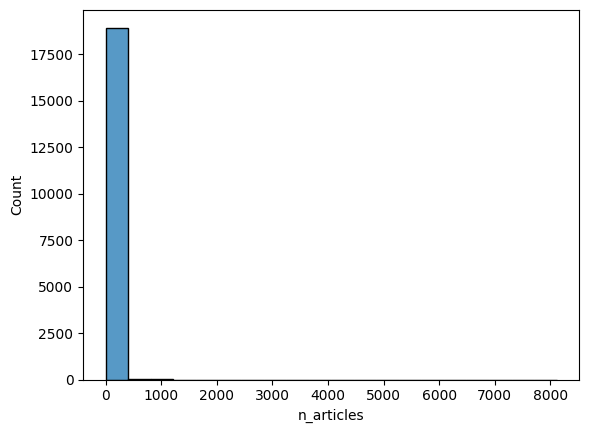

In [15]:
sns.histplot(authors_article_count["n_articles"], bins=20);

In [32]:
df_filtered["n_contributors"].describe()

count    154719.000000
mean          0.912286
std           0.421524
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          12.000000
Name: n_contributors, dtype: float64

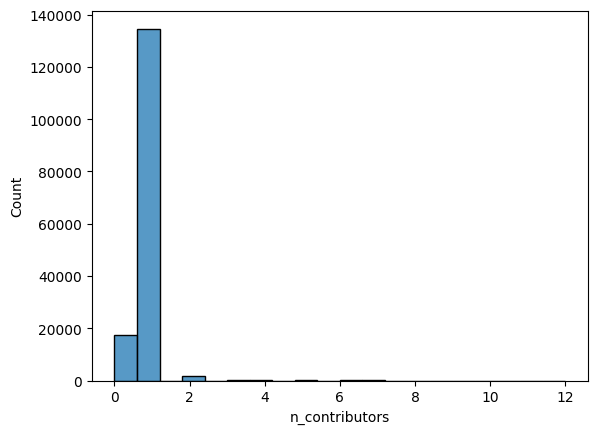

In [31]:
sns.histplot(df_filtered["n_contributors"], bins=20);

In [18]:
year_count = df_filtered.groupby("year").size().reset_index(name="count")
year_count['year'] = year_count['year'].astype(int)

/var/folders/hp/2tgr4qfj4gz39lyrkptx7w3c0000gn/T/ipykernel_12746/3118688090.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90);


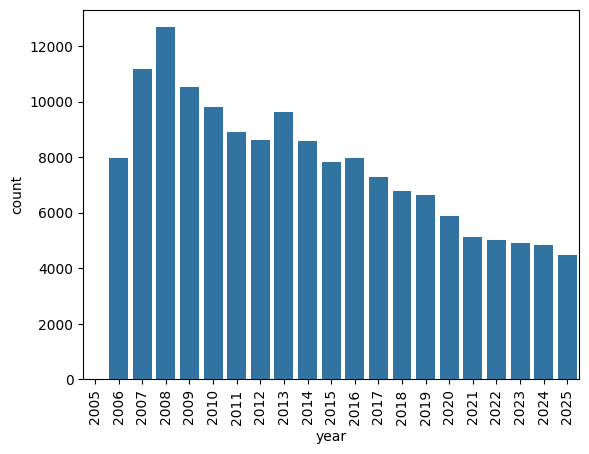

In [30]:
g = sns.barplot(year_count, x="year", y="count")
g.set_xticklabels(g.get_xticklabels(), rotation=90);